<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/Ponencia_Parte_2_ML_No_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML No Supervisado

## Presentación del dataset

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Resumen estadístico:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


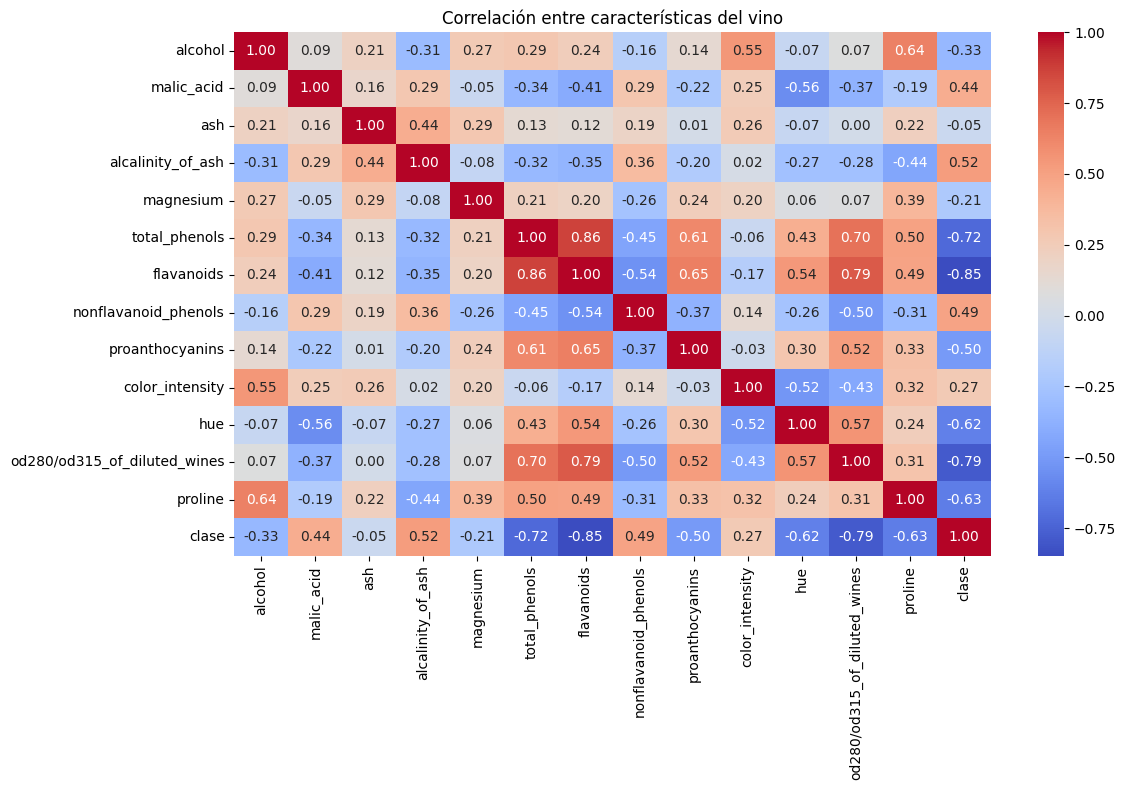

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de vinos
wine = load_wine()
X = wine.data
y = wine.target

# Crear un DataFrame para ver los datos
df_wine = pd.DataFrame(X, columns=wine.feature_names)
df_wine['clase'] = y

# Mostrar las primeras filas
display(df_wine.head())

# Estadísticas descriptivas
print("Resumen estadístico:")
display(df_wine.describe())

# Mapa de calor de correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df_wine.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlación entre características del vino")
plt.tight_layout()
plt.show()


/tmp/ipykernel_15911/4103753944.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clase', data=df_wine, palette='Set2')


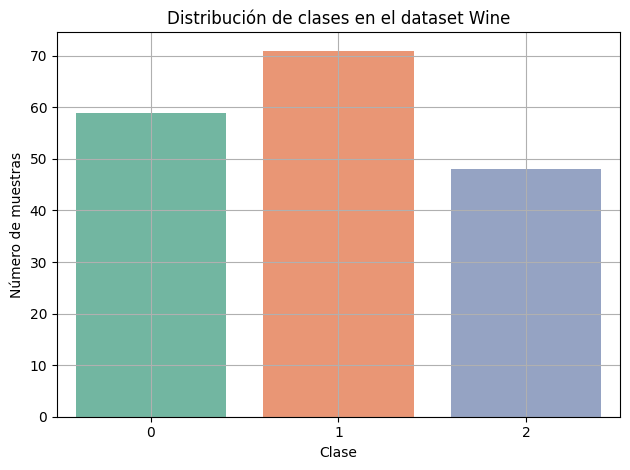

In [2]:
# Gráfico de barras del conteo de clases
sns.countplot(x='clase', data=df_wine, palette='Set2')
plt.title("Distribución de clases en el dataset Wine")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.grid(True)
plt.tight_layout()
plt.show()


## K Means

Índice de Silhouette: 0.548


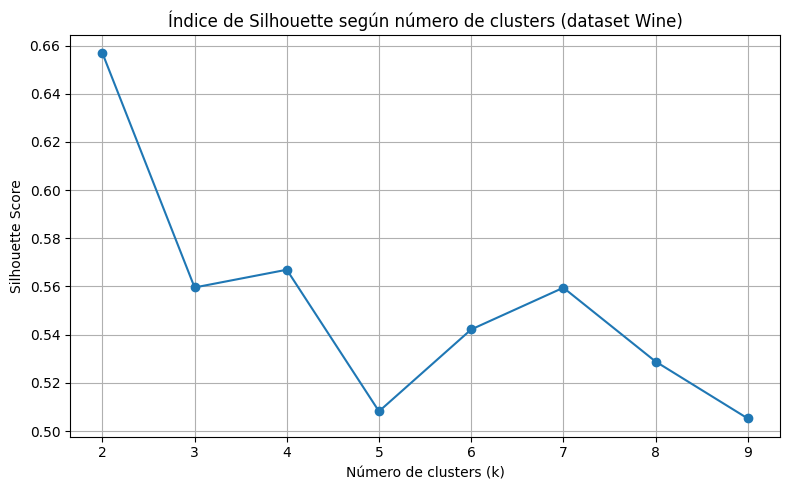

In [3]:
# En aprendizaje no supervisado no usamos etiquetas.
# Vamos a aplicar KMeans al dataset Wine sin usar sus clases verdaderas.
# Luego mediremos qué tan bien agrupa con el índice de Silhouette.

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
wine = load_wine()
X = wine.data  # Solo usamos las características

# Aplicar KMeans (buscamos 3 grupos)
kmeans = KMeans(n_clusters=3, random_state=2025)
kmeans.fit(X)
labels = kmeans.labels_

# Calcular el índice de Silhouette
# Este valor va de -1 (agrupamiento malo) a 1 (agrupamiento ideal)
silhouette = silhouette_score(X, labels)
print("Índice de Silhouette:", round(silhouette, 4))

# Recomendación:
# Silhouette > 0.5: buena separación entre grupos
# Silhouette < 0.4: agrupamientos confusos o solapados

# Analizar cómo varía el índice de Silhouette según el número de clusters
range_k = range(2, 10)
sil_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# Graficar los valores de Silhouette para cada número de clusters
plt.figure(figsize=(8, 5))
plt.plot(range_k, sil_scores, marker='o')
plt.title("Índice de Silhouette según número de clusters (dataset Wine)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretación

# Este gráfico nos ayuda a elegir el número óptimo de clusters.
# Cuanto más alto es el Silhouette Score, mejor es la separación entre grupos.
# Un valor cercano a 1 significa que los puntos están bien agrupados.
# Un valor cercano a 0 indica que los puntos están en el límite entre grupos.
# Si el score baja mucho, puede significar que hay demasiados clusters y no hay separación clara.

# El valor más alto es cuando k=2: el agrupamiento es más claro y definido en dos grupos.
# A partir de k=3, el Silhouette Score baja, esto indica que los grupos empiezan a solaparse o perder cohesión.

# Aunque sabemos que el dataset tiene 3 clases reales, el modelo sin etiquetas
# encontró una estructura más fuerte cuando separa en 2 grupos.

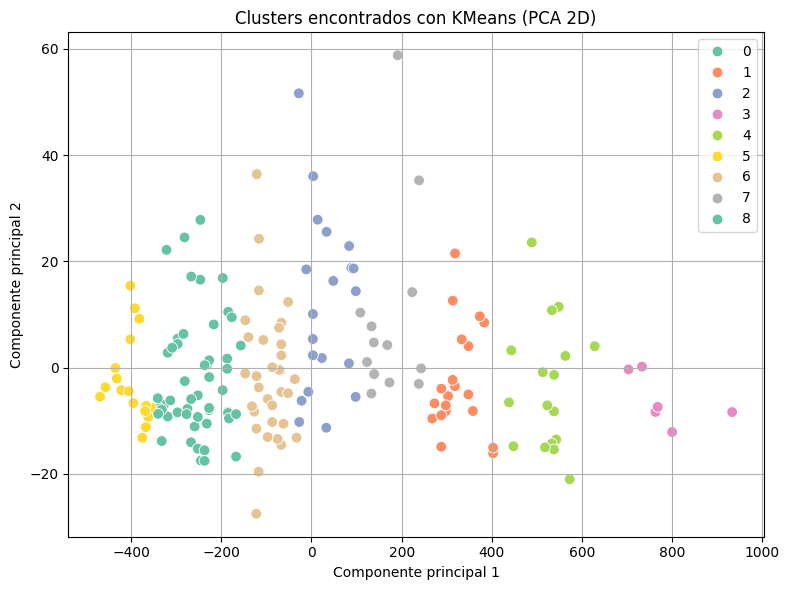

In [4]:
# ============================================
# Reducción de dimensiones con PCA (Pasamos a 2D)
# Para visualizar los clusters de KMeans
# ============================================

from sklearn.decomposition import PCA

# Reducimos los datos a 2 dimensiones
X_pca = PCA(n_components=2).fit_transform(X)
# Cada componente representa una característica

# Dibujamos los clusters encontrados por KMeans
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=60)
plt.title("Clusters encontrados con KMeans (PCA 2D)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.grid(True)
plt.tight_layout()
plt.show()



In [5]:
# ============================================
# Comparar los clusters con las clases reales
# ============================================

import pandas as pd

# Creamos un DataFrame con etiquetas reales y de clustering
df_clusters = pd.DataFrame({
    'Cluster': labels,
    'Clase Real': wine.target
})

# Mostramos una tabla cruzada para ver la correspondencia
print("Relación entre clusters y clases reales:")
print(pd.crosstab(df_clusters['Cluster'], df_clusters['Clase Real']))


Relación entre clusters y clases reales:
Clase Real   0   1   2
Cluster               
0            0  16  14
1           20   0   0
2            8   3   9
3            6   0   0
4           17   0   0
5            0  17   0
6            1  14  18
7            7   4   2
8            0  17   5


## DBSCANS

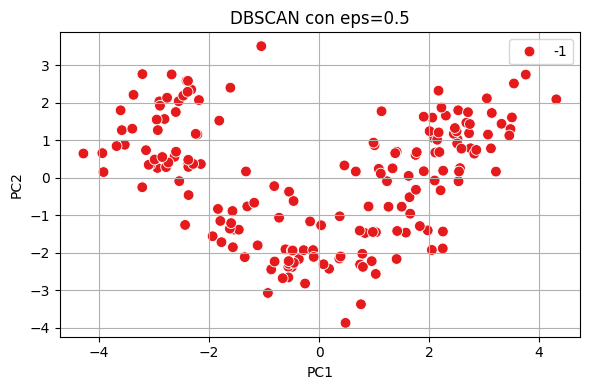

eps = 0.5 : clusters encontrados: 0, puntos ruido: 178


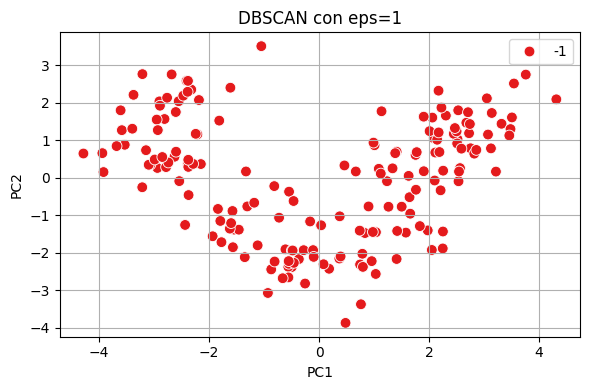

eps = 1 : clusters encontrados: 0, puntos ruido: 178


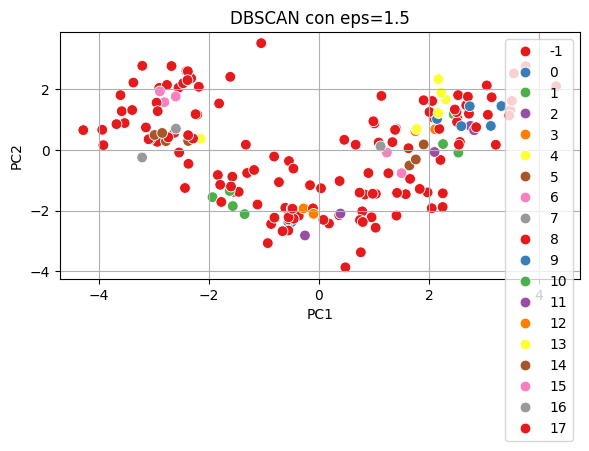

eps = 1.5 : clusters encontrados: 18, puntos ruido: 127


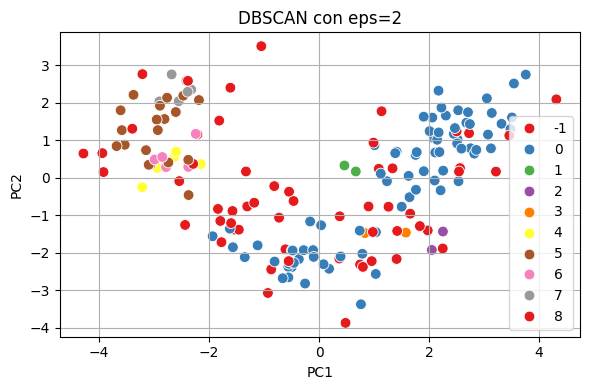

eps = 2 : clusters encontrados: 9, puntos ruido: 56


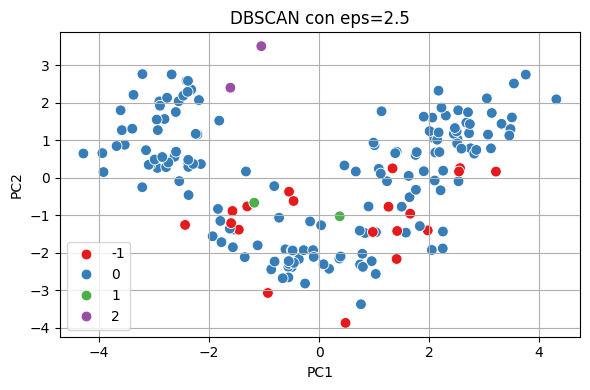

eps = 2.5 : clusters encontrados: 3, puntos ruido: 19


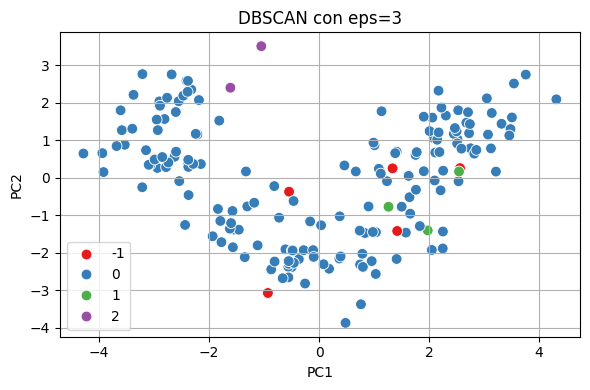

eps = 3 : clusters encontrados: 3, puntos ruido: 5


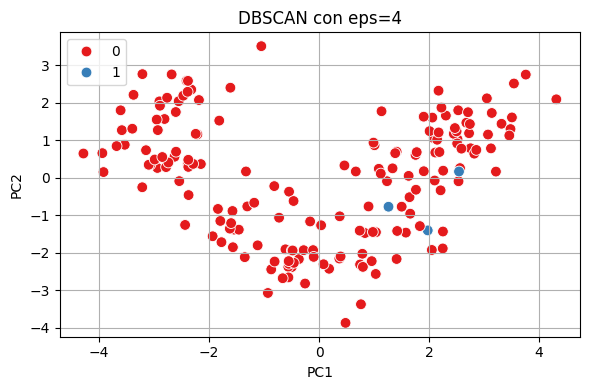

eps = 4 : clusters encontrados: 2, puntos ruido: 0


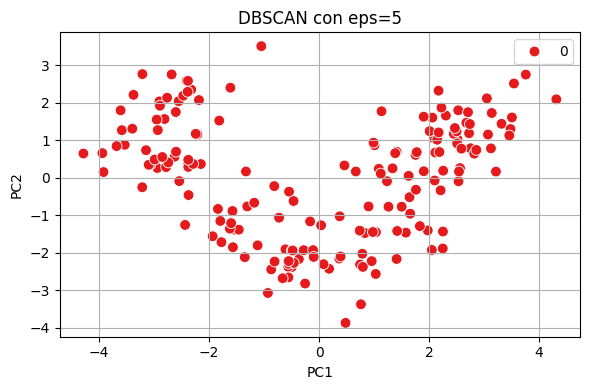

eps = 5 : clusters encontrados: 1, puntos ruido: 0


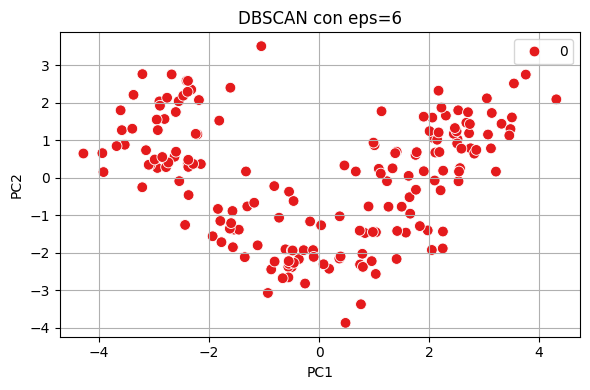

eps = 6 : clusters encontrados: 1, puntos ruido: 0


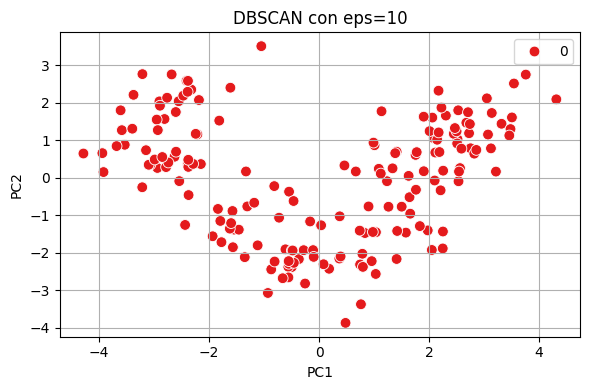

eps = 10 : clusters encontrados: 1, puntos ruido: 0
Número de puntos marcados como ruido: 0


In [6]:
# DBSCAN con escalado previo (StandardScaler)

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
wine = load_wine()
X = wine.data

# Escalar características para que el parámetro eps tenga sentido

# Diferencias entre escaladores:
#
# StandardScaler:
# - Centra los datos en media 0 y desviación estándar 1
# - Preserva la forma de la distribución original
# - Hace que todas las variables contribuyan por igual a la distancia
# - Recomendado para algoritmos que usan distancias como DBSCAN y KMeans
#
# MinMaxScaler:
# - Escala los valores al rango [0, 1]
# - Preserva la forma general, pero sensible a valores extremos
# - Útil si necesitas conservar proporciones relativas
#
# RobustScaler:
# - Escala usando la mediana y el rango intercuartílico
# - No se ve afectado por outliers
# - Recomendado si el dataset tiene valores atípicos
#
# En este caso usamos StandardScaler porque:
# - Queremos normalizar todas las variables con el mismo peso
# - Es el estándar para algoritmos de clustering basados en distancia

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Probar varios valores de eps
from collections import Counter

eps_values = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 10]

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=2)
    labels_db = dbscan.fit_predict(X_scaled)
    X_pca = PCA(n_components=2).fit_transform(X_scaled)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_db, palette='Set1', s=60)
    plt.title(f"DBSCAN con eps={eps}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    unique_labels = set(labels_db)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    print(f"eps = {eps} : clusters encontrados: {n_clusters}, puntos ruido: {Counter(labels_db)[-1] if -1 in labels_db else 0}")

# Nota: DBSCAN asigna -1 a los puntos que considera ruido (outliers)
# Para ver cuántos hay con:
print("Número de puntos marcados como ruido:", sum(labels_db == -1))


In [7]:
"""
Reflexiones:

Si agrupamos demasiado (pocos clústeres): se pierde detalle. No es bueno.
Si hay dispersión (muchos clústeres): Hay fragmentación, hay ruido. No es bueno.
Si hay un número razonable de clústeres: es bueno. Pero, ¿cómo lo sé?
    Comparar con el test de Silhouette: 3 clases
"""

'\nReflexiones:\n\nSi agrupamos demasiado (pocos clústeres): se pierde detalle. No es bueno.\nSi hay dispersión (muchos clústeres): Hay fragmentación, hay ruido. No es bueno.\nSi hay un número razonable de clústeres: es bueno. Pero, ¿cómo lo sé?\n    Comparar con el test de Silhouette: 3 clases\n'

## Agglomerative Clustering

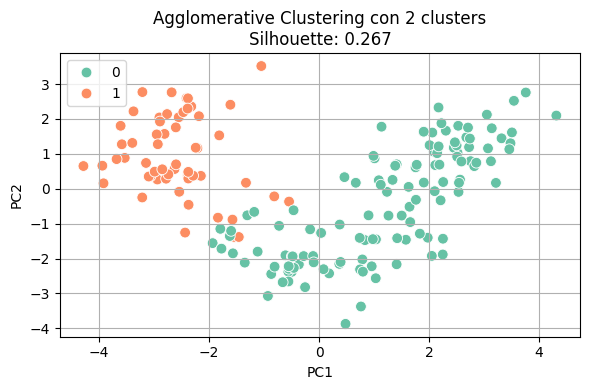

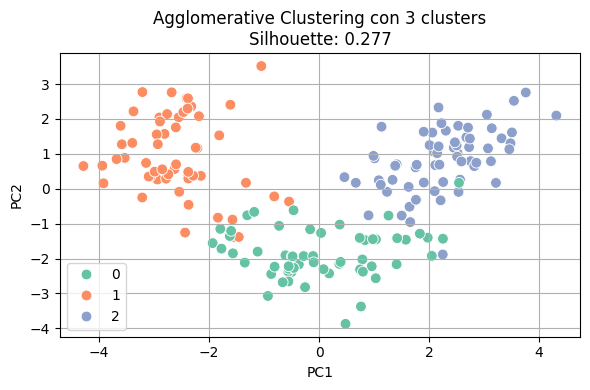

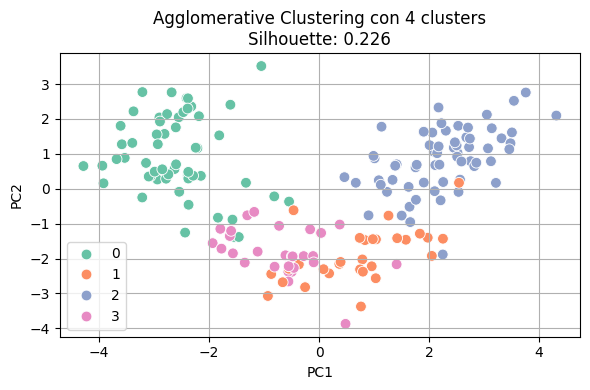

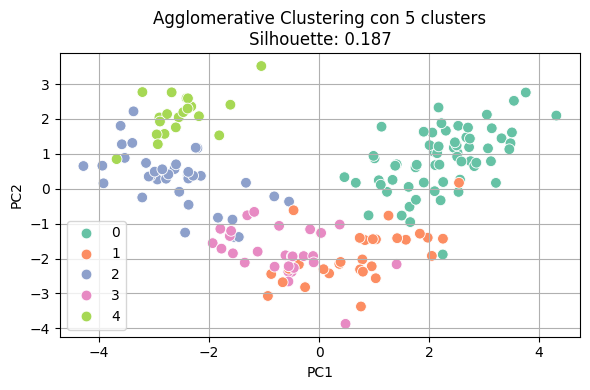

In [8]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering, MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import numpy as np

# Cargar y escalar datos
wine = load_wine()
X = wine.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción a 2D para visualización
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# Agglomerative Clustering
# Este algoritmo forma grupos juntando datos similares de forma jerárquica
# El parámetro n_clusters indica cuántos grupos cortar del árbol de jerarquía
# Vamos a iterar entre 2 y 6 clústeres

for k in range(2, 6):
    agg = AgglomerativeClustering(n_clusters=k)
    labels_agg = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_agg)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agg, palette='Set2', s=60)
    plt.title(f"Agglomerative Clustering con {k} clusters\nSilhouette: {round(sil, 3)}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


##  Gaussian Mixture Models

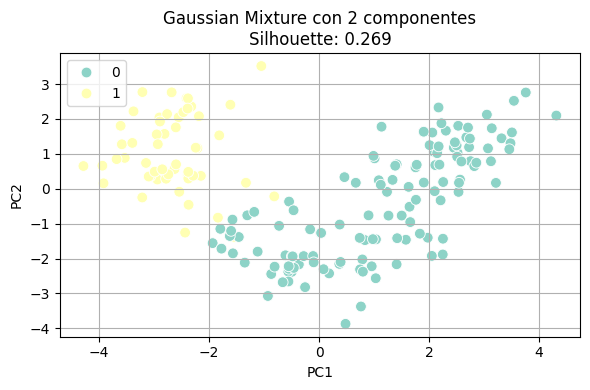

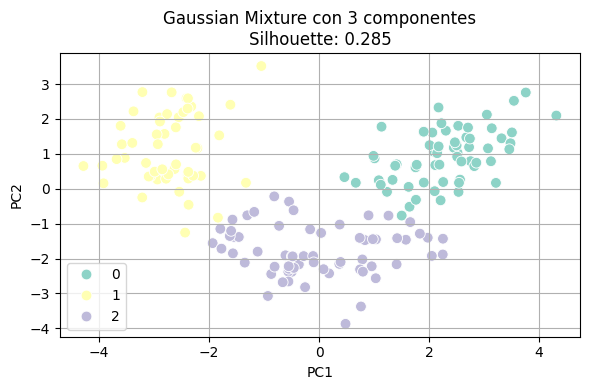

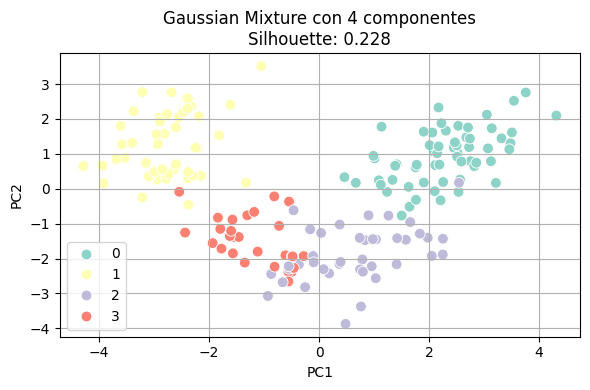

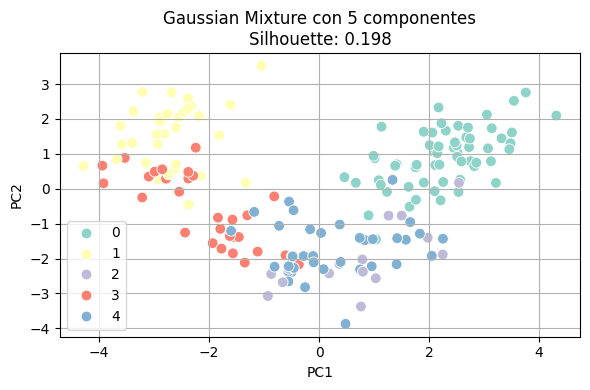

In [9]:
from sklearn.mixture import GaussianMixture

# Gaussian Mixture Models (GMM)

# GMM modela los datos como combinaciones de distribuciones normales
# El parámetro n_components indica cuántas 'mezclas' (grupos) probar

for k in range(2, 6):
    gmm = GaussianMixture(n_components=k, random_state=2025)
    labels_gmm = gmm.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_gmm)

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_gmm, palette='Set3', s=60)
    plt.title(f"Gaussian Mixture con {k} componentes\nSilhouette: {round(sil, 3)}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## MeanShift

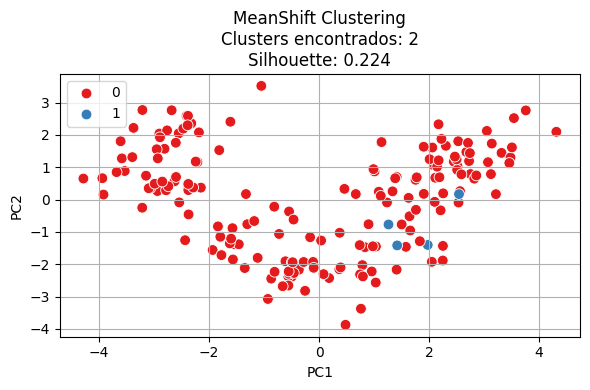

In [10]:
# MeanShift

# MeanShift busca los máximos de densidad sin necesidad de definir k
# Puede ser más lento pero detecta automáticamente los grupos

mean_shift = MeanShift()
labels_ms = mean_shift.fit_predict(X_scaled)
sil = silhouette_score(X_scaled, labels_ms)

plt.figure(figsize=(6, 4))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_ms, palette='Set1', s=60)
plt.title(f"MeanShift Clustering\nClusters encontrados: {len(set(labels_ms))}\nSilhouette: {round(sil, 3)}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

#A diferencia de KMeans o GMM, no se le indica cuántos clusters formar.
# Si el dataset tiene una o dos zonas muy densas (y las demás más dispersas), puede fusionar todo lo demás en uno o dos clústeres.
# Es sensible al parámetro bandwidth, que por defecto se estima automáticamente.




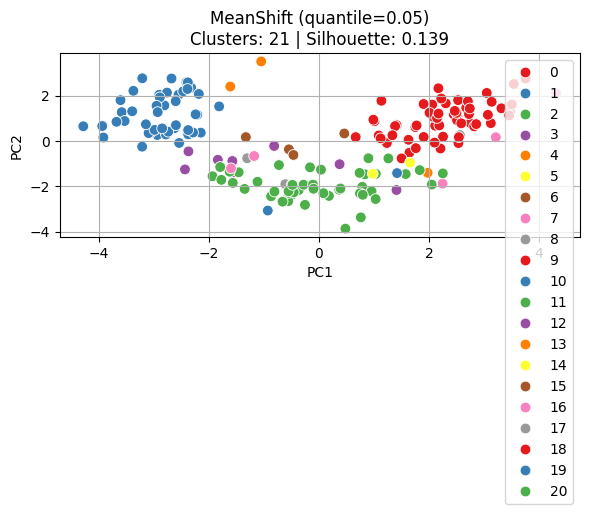

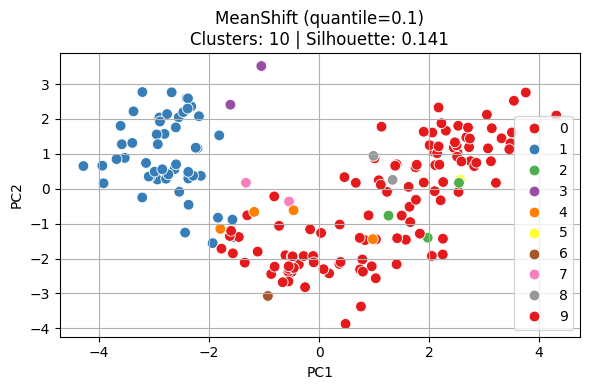

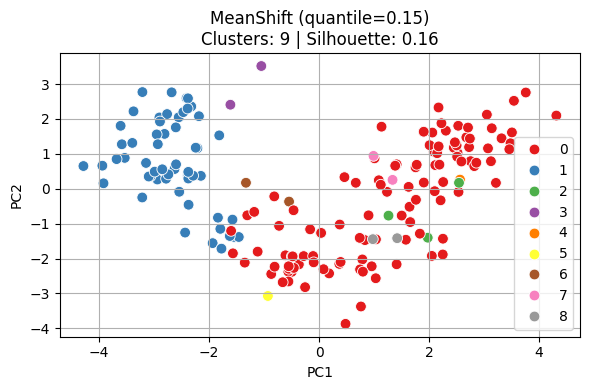

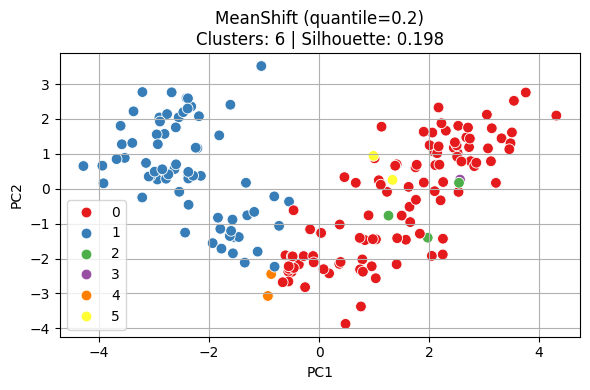

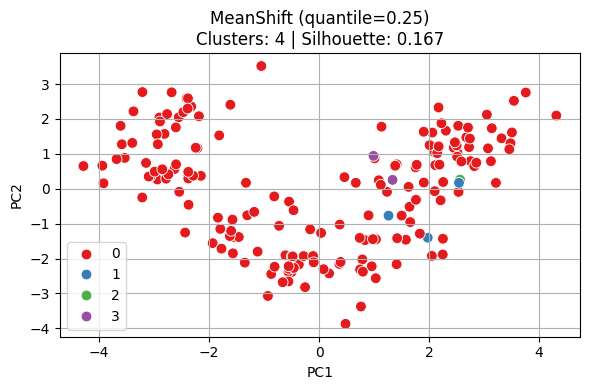

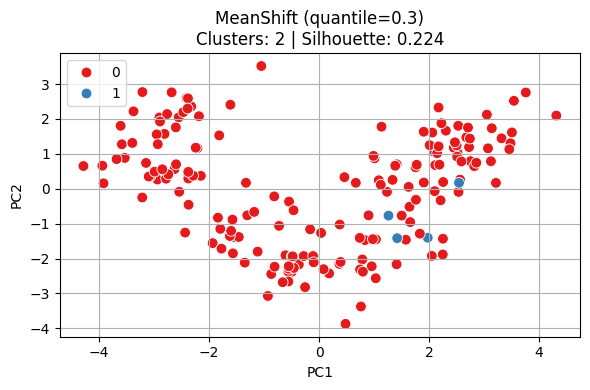

   quantile  bandwidth  n_clusters  silhouette
5      0.30      4.093           2      0.2245
3      0.20      3.551           6      0.1981
4      0.25      3.811           4      0.1672
2      0.15      3.287           9      0.1597
1      0.10      3.003          10      0.1409
0      0.05      2.599          21      0.1390


In [11]:
# Vamos a iterar el parámetro
# ================================
# MeanShift con variación de bandwidth
# ================================

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
import numpy as np

# Cargar y escalar datos
wine = load_wine()
X = wine.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reducción a 2D para visualización
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# ¿Qué es bandwidth?

# bandwidth es el tamaño del radio que se usa para estimar la densidad local
# Cuanto más grande el bandwidth, más datos se agrupan juntos
# Cuanto más pequeño, más grupos pueden detectarse
# Un valor muy pequeño puede fragmentar mucho los datos, uno grande puede agrupar todo en un solo cluster

# Probamos distintos valores de bandwidth usando quantile para estimarlo
quantiles = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

for q in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=q, n_samples=200)
    mean_shift = MeanShift(bandwidth=bandwidth)
    labels_ms = mean_shift.fit_predict(X_scaled)
    n_clusters = len(set(labels_ms))

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels_ms)
        silhouette_text = f"Silhouette: {round(sil, 3)}"
    else:
        silhouette_text = "Silhouette: N/A"

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_ms, palette='Set1', s=60)
    plt.title(f"MeanShift (quantile={q})\nClusters: {n_clusters} | {silhouette_text}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

"""
Lo ideal es elegir aquel valor que logre un buen equilibrio entre:
Número razonable de clústeres
Silhouette alto
"""

resultados = []

for q in quantiles:
    bandwidth = estimate_bandwidth(X_scaled, quantile=q, n_samples=200)
    mean_shift = MeanShift(bandwidth=bandwidth)
    labels_ms = mean_shift.fit_predict(X_scaled)
    n_clusters = len(set(labels_ms))

    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels_ms)
    else:
        sil = None

    resultados.append({
        'quantile': q,
        'bandwidth': round(bandwidth, 3),
        'n_clusters': n_clusters,
        'silhouette': round(sil, 4) if sil else "N/A"
    })

import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados.sort_values(by="silhouette", ascending=False))
